# 📌 Tugas 7 - Exploratory Data Analysis

- **Nama lengkap**: Stefani Kelin Martha Ampak
- **Program**: AI Development

---

Dataset: **Worldometer COVID-19** (`worldometer_data.csv`)

Setiap langkah, setiap cell terdapat *insight* hasil analisis dari kode yang dijalankan.


## 0. Import Module yang Diperlukan

In [1]:
# Sesuaikan path dataset jika diperlukan
# Jika di Google Colab, upload file terlebih dahulu atau mount Google Drive
DATA_PATH = 'worldometer_data.csv'  # Ganti jika perlu, misal: '/content/worldometer_data.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
print("Semua module berhasil diimport.")

Semua module berhasil diimport.


## 1. Membaca Data

> Membaca data teratas dan terbawah dengan `head()` dan `tail()`
> Cek tipe data dan missing value
> Tampilkan statistik deskriptif

In [3]:
df = pd.read_csv(DATA_PATH)
print("5 Baris Pertama:")
display(df.head())
print("\n 5 Baris Terakhir:")
display(df.tail())

5 Baris Pertama:


,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa



 5 Baris Terakhir:


,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
204,Montserrat,North America,4992.0,13,NaN,1.0,NaN,10.0,NaN,2.0,NaN,2604.0,200.0,61.0,12220.0,NaN
205,Caribbean Netherlands,North America,26247.0,13,NaN,NaN,NaN,7.0,NaN,6.0,NaN,495.0,NaN,424.0,16154.0,NaN
206,Falkland Islands,South America,3489.0,13,NaN,NaN,NaN,13.0,NaN,0.0,NaN,3726.0,NaN,1816.0,520493.0,NaN
207,Vatican City,Europe,801.0,12,NaN,NaN,NaN,12.0,NaN,0.0,NaN,14981.0,NaN,NaN,NaN,Europe
208,Western Sahara,Africa,598682.0,10,NaN,1.0,NaN,8.0,NaN,1.0,NaN,17.0,2.0,NaN,NaN,Africa


In [4]:
print(" Tipe Data:")
print(df.dtypes)
print("\n Missing Values per Kolom:")
print(df.isnull().sum())
print(f"\nTotal baris: {df.shape[0]}, Total kolom: {df.shape[1]}")

 Tipe Data:
Country/Region       object
Continent            object
Population          float64
TotalCases            int64
NewCases            float64
TotalDeaths         float64
NewDeaths           float64
TotalRecovered      float64
NewRecovered        float64
ActiveCases         float64
Serious,Critical    float64
Tot Cases/1M pop    float64
Deaths/1M pop       float64
TotalTests          float64
Tests/1M pop        float64
WHO Region           object
dtype: object

 Missing Values per Kolom:
Country/Region        0
Continent             1
Population            1
TotalCases            0
NewCases            205
TotalDeaths          21
NewDeaths           206
TotalRecovered        4
NewRecovered        206
ActiveCases           4
Serious,Critical     87
Tot Cases/1M pop      1
Deaths/1M pop        22
TotalTests           18
Tests/1M pop         18
WHO Region           25
dtype: int64

Total baris: 209, Total kolom: 16


In [5]:
print(" Statistik Deskriptif:")
display(df.describe())

 Statistik Deskriptif:


,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop
count,2.080000e+02,2.090000e+02,4.000000,188.000000,3.000000,2.050000e+02,3.000000,2.050000e+02,122.000000,208.000000,187.000000,1.910000e+02,191.000000
mean,3.041549e+07,9.171850e+04,1980.500000,3792.590426,300.000000,5.887898e+04,1706.000000,2.766433e+04,534.393443,3196.024038,98.681176,1.402405e+06,83959.366492
std,1.047661e+08,4.325867e+05,3129.611424,15487.184877,451.199512,2.566984e+05,2154.779803,1.746327e+05,2047.518613,5191.986457,174.956862,5.553367e+06,152730.591240
min,8.010000e+02,1.000000e+01,20.000000,1.000000,1.000000,7.000000e+00,42.000000,0.000000e+00,1.000000,3.000000,0.080000,6.100000e+01,4.000000
25%,9.663140e+05,7.120000e+02,27.500000,22.000000,40.500000,3.340000e+02,489.000000,8.600000e+01,3.250000,282.000000,6.000000,2.575200e+04,8956.500000
50%,7.041972e+06,4.491000e+03,656.000000,113.000000,80.000000,2.178000e+03,936.000000,8.990000e+02,27.500000,1015.000000,29.000000,1.357020e+05,32585.000000
75%,2.575614e+07,3.689600e+04,2609.000000,786.000000,449.500000,2.055300e+04,2538.000000,7.124000e+03,160.250000,3841.750000,98.000000,7.576960e+05,92154.500000
max,1.381345e+09,5.032179e+06,6590.000000,162804.000000,819.000000,2.576668e+06,4140.000000,2.292707e+06,18296.000000,39922.000000,1238.000000,6.313960e+07,995282.000000


**Insight:**
- Dataset berisi **209 negara/wilayah** dengan **16 kolom** fitur terkait COVID-19.
- Kolom utama meliputi: `TotalCases`, `TotalDeaths`, `TotalRecovered`, `ActiveCases`, `TotalTests`, dan `Population`.
- Terdapat cukup banyak **missing value**, terutama pada `NewCases` (205), `NewDeaths` (206), `NewRecovered` (206), dan `Serious,Critical` (87) — kemungkinan karena data baru belum tersedia saat snapshot diambil.
- Distribusi data sangat **skewed ke kanan** (mean jauh di atas median untuk TotalCases dan Population), mencerminkan ketidakmerataan pandemi antar negara.
- Amerika Serikat mendominasi dengan TotalCases tertinggi (~5 juta), jauh melampaui negara lain.


## 2. Analisis Distribusi

> Plot distribusi TotalCases, TotalDeaths, dan TotalRecovered
> Buat histogram log-skala untuk TotalCases
> Bandingkan populasi terhadap jumlah kasus (scatter plot)

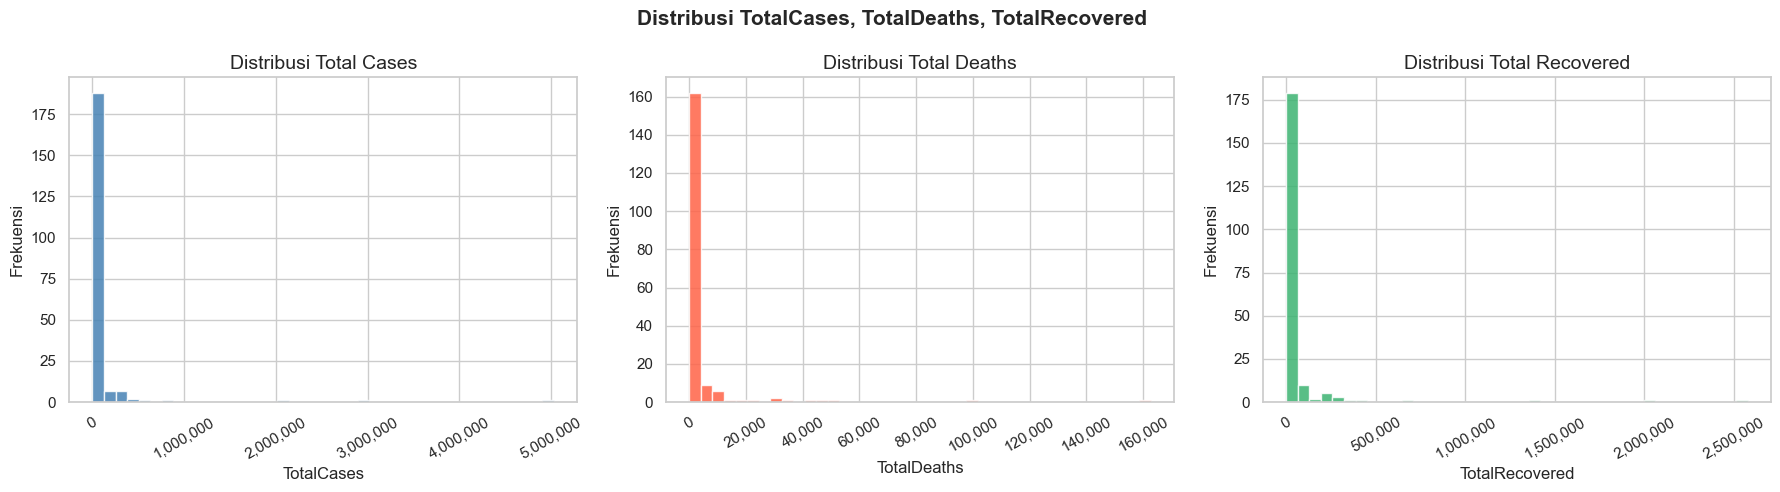

 Plot distribusi tersimpan.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cols = ['TotalCases', 'TotalDeaths', 'TotalRecovered']
colors = ['steelblue', 'tomato', 'mediumseagreen']
titles = ['Total Cases', 'Total Deaths', 'Total Recovered']

for ax, col, color, title in zip(axes, cols, colors, titles):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribusi {title}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.setp(ax.get_xticklabels(), rotation=30)

plt.suptitle('Distribusi TotalCases, TotalDeaths, TotalRecovered', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_cases.png', dpi=100, bbox_inches='tight')
plt.show()
print(" Plot distribusi tersimpan.")

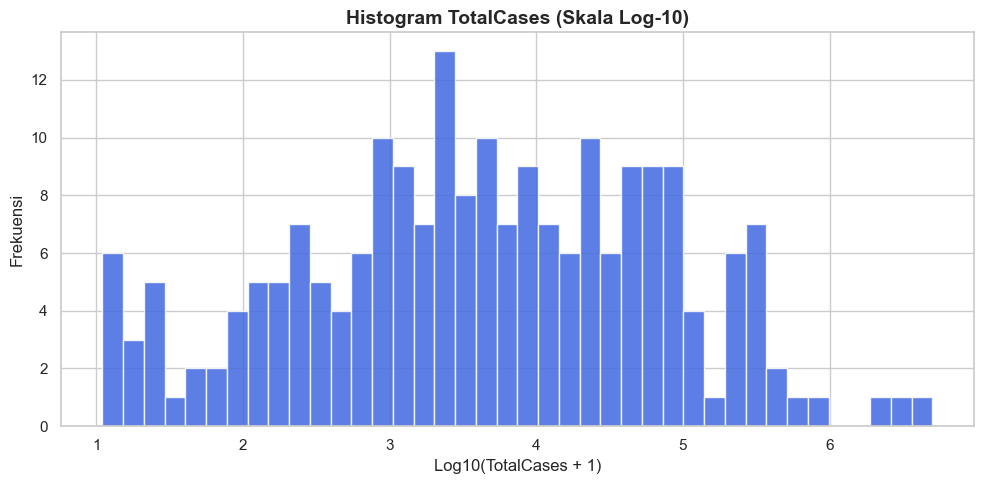

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
data_log = np.log10(df['TotalCases'].dropna() + 1)
ax.hist(data_log, bins=40, color='royalblue', edgecolor='white', alpha=0.85)
ax.set_title('Histogram TotalCases (Skala Log-10)', fontsize=14, fontweight='bold')
ax.set_xlabel('Log10(TotalCases + 1)')
ax.set_ylabel('Frekuensi')
plt.tight_layout()
plt.savefig('hist_log.png', dpi=100, bbox_inches='tight')
plt.show()

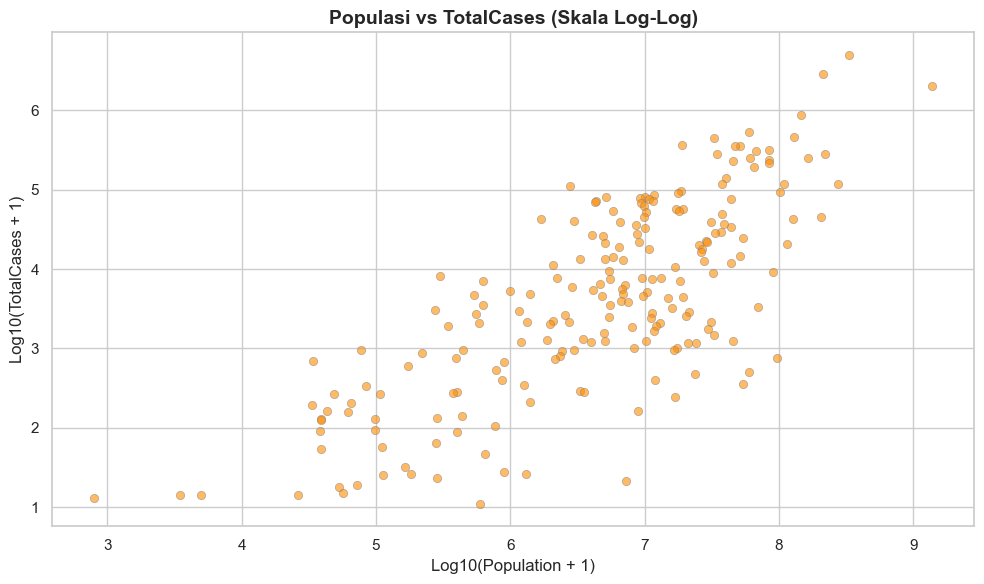

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

df_clean = df.dropna(subset=['Population', 'TotalCases'])

ax.scatter(
    np.log10(df_clean['Population'] + 1),
    np.log10(df_clean['TotalCases'] + 1),
    color='darkorange', alpha=0.6, edgecolors='grey', linewidths=0.5
)
ax.set_title('Populasi vs TotalCases (Skala Log-Log)', fontsize=14, fontweight='bold')
ax.set_xlabel('Log10(Population + 1)')
ax.set_ylabel('Log10(TotalCases + 1)')
plt.tight_layout()
plt.savefig('scatter_pop_cases.png', dpi=100, bbox_inches='tight')
plt.show()

**Insight:**
- Distribusi `TotalCases`, `TotalDeaths`, dan `TotalRecovered` sangat **right-skewed** — mayoritas negara memiliki angka rendah, namun beberapa negara besar menarik rata-rata jauh ke atas.
- Pada **histogram log-skala**, distribusi TotalCases mendekati **normal** di ruang logaritmik, mengindikasikan variabilitas eksponen yang besar antar negara.
- **Scatter plot Populasi vs TotalCases** dalam skala log-log menunjukkan **korelasi positif lemah-sedang**: negara berpopulasi lebih besar cenderung memiliki kasus lebih banyak, namun tidak selalu — faktor kebijakan, pengujian, dan kepadatan lebih menentukan.


## 3. Analisis Per Benua (Continent)

> Hitung total kasus, kematian, dan kesembuhan per benua
> Visualisasikan perbandingan kasus dan kematian antar benua

📊 Total Statistik per Benua:


,Continent,TotalCases,TotalDeaths,TotalRecovered
4,North America,5919209,229855.0,3151678.0
1,Asia,4689794,100627.0,3508170.0
5,South America,4543273,154885.0,3116150.0
3,Europe,2982576,205232.0,1587302.0
0,Africa,1011867,22114.0,693620.0
2,Australia/Oceania,21735,281.0,12620.0


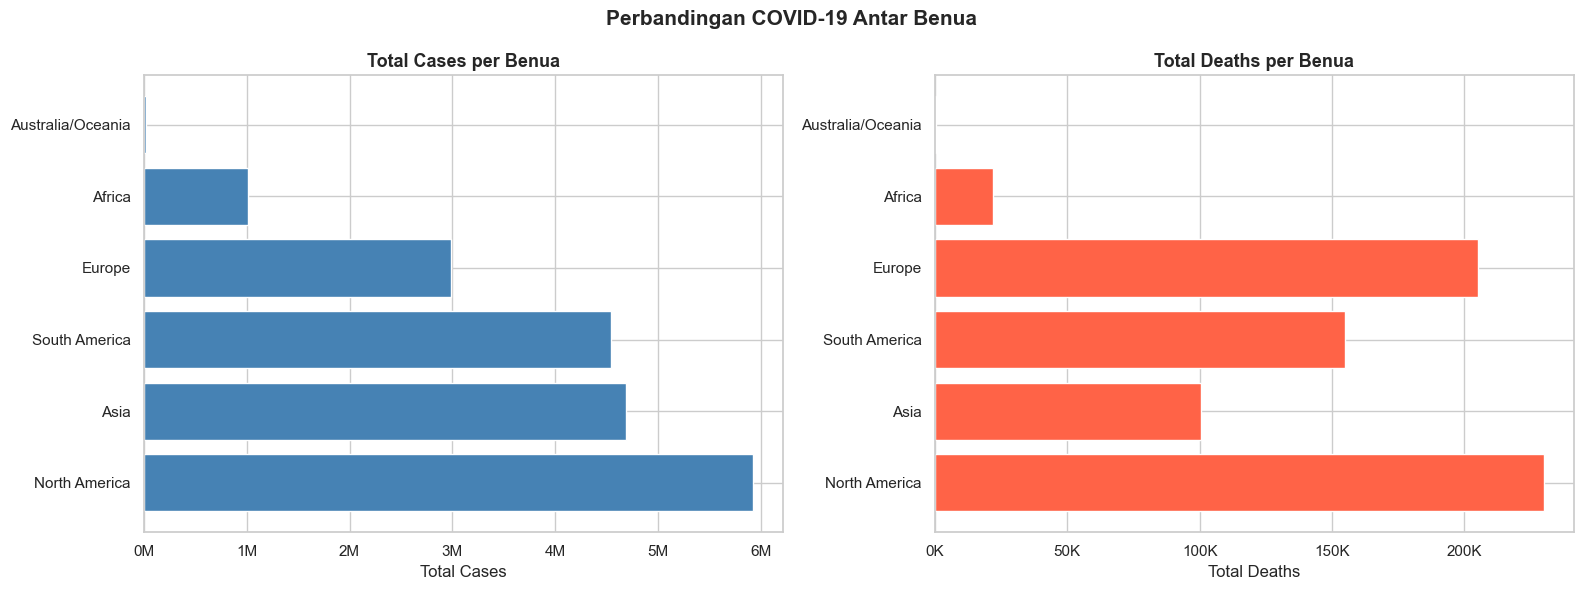

In [9]:
df_clean = df.dropna(subset=['Continent'])
continent_stats = df_clean.groupby('Continent')[['TotalCases', 'TotalDeaths', 'TotalRecovered']].sum().reset_index()
continent_stats = continent_stats.sort_values('TotalCases', ascending=False)
print("📊 Total Statistik per Benua:")
display(continent_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kasus
axes[0].barh(continent_stats['Continent'], continent_stats['TotalCases'], color='steelblue', edgecolor='white')
axes[0].set_title('Total Cases per Benua', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Cases')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))

# Kematian
axes[1].barh(continent_stats['Continent'], continent_stats['TotalDeaths'], color='tomato', edgecolor='white')
axes[1].set_title('Total Deaths per Benua', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Deaths')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

plt.suptitle('Perbandingan COVID-19 Antar Benua', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('continent_stats.png', dpi=100, bbox_inches='tight')
plt.show()

**Insight:**
- **Amerika Utara** memiliki total kasus tertinggi, diikuti **Asia** dan **Eropa** — mencerminkan skala pandemi di negara-negara berpopulasi besar seperti AS, India, dan Brazil.
- **Eropa** mencatat angka kematian yang relatif tinggi dibandingkan kasusnya, mengindikasikan **case fatality rate** (CFR) yang lebih besar dibanding benua lain.
- **Afrika** dan **Oseania** memiliki angka kasus dan kematian terendah, kemungkinan dipengaruhi oleh kapasitas pengujian yang lebih rendah sehingga kasus tidak terdeteksi penuh.
- Perbedaan antar benua yang ekstrem menunjukkan bahwa pandemi tidak terdistribusi secara merata secara global.


## 4. Analisis Tes dan Positivity Rate

> Buat kolom baru "Positivity Rate" = TotalCases / TotalTests
> Analisis negara-negara dengan positivity rate tertinggi

In [10]:
df['Positivity Rate'] = df['TotalCases'] / df['TotalTests']
pos_rate = df[['Country/Region', 'Continent', 'TotalCases', 'TotalTests', 'Positivity Rate']].dropna(subset=['Positivity Rate'])
pos_rate = pos_rate[pos_rate['Positivity Rate'] <= 1]  # Filter nilai tidak wajar
top_pos = pos_rate.nlargest(15, 'Positivity Rate')

print("Top 15 Negara dengan Positivity Rate Tertinggi:")
display(top_pos)

Top 15 Negara dengan Positivity Rate Tertinggi:


,Country/Region,Continent,TotalCases,TotalTests,Positivity Rate
126,Suriname,South America,2096,2785.0,0.752603
26,Egypt,Africa,95006,135000.0,0.703748
87,Guinea,Africa,7664,14407.0,0.531964
28,Bolivia,South America,86423,183583.0,0.470757
5,Mexico,North America,462690,1056915.0,0.437774
46,Honduras,North America,45098,109292.0,0.412638
88,Haiti,North America,7544,18443.0,0.409044
52,Afghanistan,Asia,36896,90396.0,0.408160
27,Ecuador,South America,90537,258582.0,0.350129
42,Guatemala,North America,54339,172712.0,0.314622


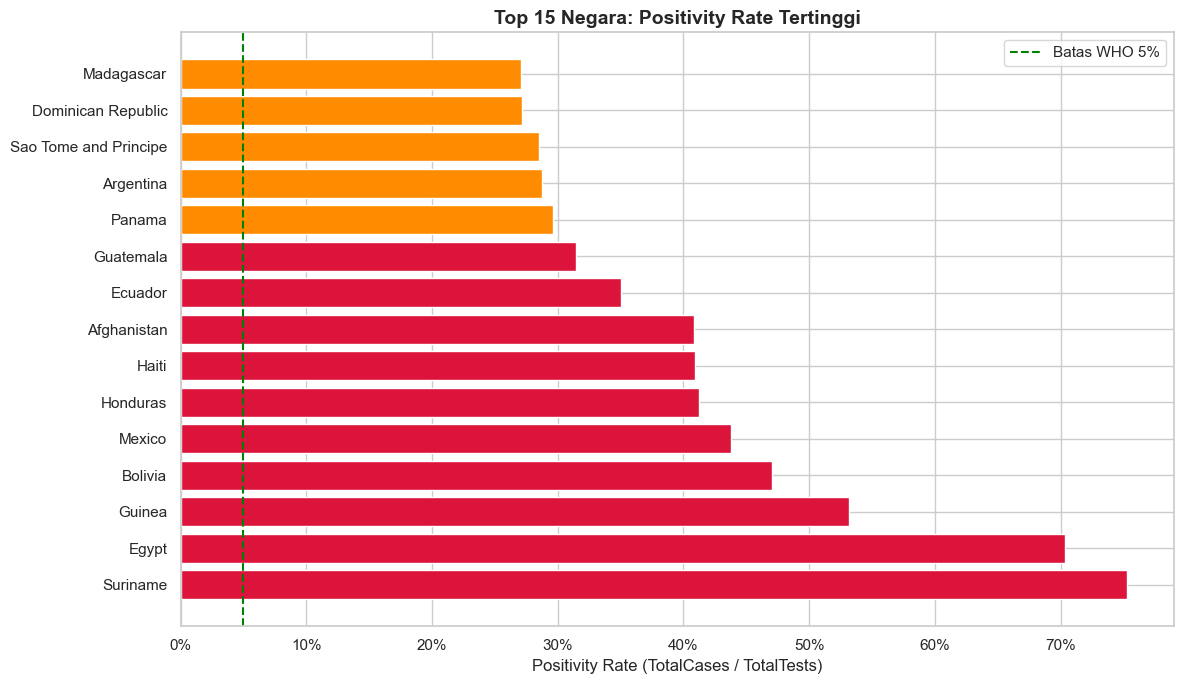

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = ['crimson' if r > 0.3 else 'darkorange' if r > 0.1 else 'steelblue' for r in top_pos['Positivity Rate']]
bars = ax.barh(top_pos['Country/Region'], top_pos['Positivity Rate'], color=colors_bar, edgecolor='white')

ax.axvline(x=0.05, color='green', linestyle='--', linewidth=1.5, label='Batas WHO 5%')
ax.set_title('Top 15 Negara: Positivity Rate Tertinggi', fontsize=14, fontweight='bold')
ax.set_xlabel('Positivity Rate (TotalCases / TotalTests)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('positivity_rate.png', dpi=100, bbox_inches='tight')
plt.show()

**Insight:**
- Negara-negara dengan positivity rate sangat tinggi (>30%) mengindikasikan kapasitas testing yang sangat rendah hanya mereka yang benar-benar sakit parah yang diuji.
- WHO merekomendasikan positivity rate di bawah 5% sebagai indikator testing yang memadai; hampir semua negara dalam daftar ini jauh melampaui ambang tersebut.
- Tingginya positivity rate berarti kasus aktual di lapangan bisa jauh lebih besar dari yang tercatat underreporting menjadi masalah serius.
- Negara-negara Afrika Sub-Sahara dan Asia Selatan mendominasi daftar ini, mencerminkan keterbatasan infrastruktur kesehatan.


## 5. Death Rate & Recovery Rate

> Buat kolom "Death Rate" = TotalDeaths / TotalCases
> Buat kolom "Recovery Rate" = TotalRecovered / TotalCases
> Bandingkan death rate dan recovery rate secara global

In [12]:
df['Death Rate'] = df['TotalDeaths'] / df['TotalCases']
df['Recovery Rate'] = df['TotalRecovered'] / df['TotalCases']

dr_rr = df[['Country/Region', 'Continent', 'TotalCases', 'Death Rate', 'Recovery Rate']].dropna()
dr_rr = dr_rr[dr_rr['TotalCases'] >= 1000]  # Filter negara dengan kasus signifikan

print(f"Data setelah filter (min 1000 kasus): {dr_rr.shape[0]} negara")
print("\n Statistik Death Rate & Recovery Rate:")
display(dr_rr[['Death Rate', 'Recovery Rate']].describe())

Data setelah filter (min 1000 kasus): 141 negara

 Statistik Death Rate & Recovery Rate:


,Death Rate,Recovery Rate
count,141.000000,141.000000
mean,0.029784,0.694874
std,0.033997,0.197105
min,0.000495,0.133634
25%,0.012341,0.544688
50%,0.021739,0.719672
75%,0.035180,0.868108
max,0.287330,0.971319


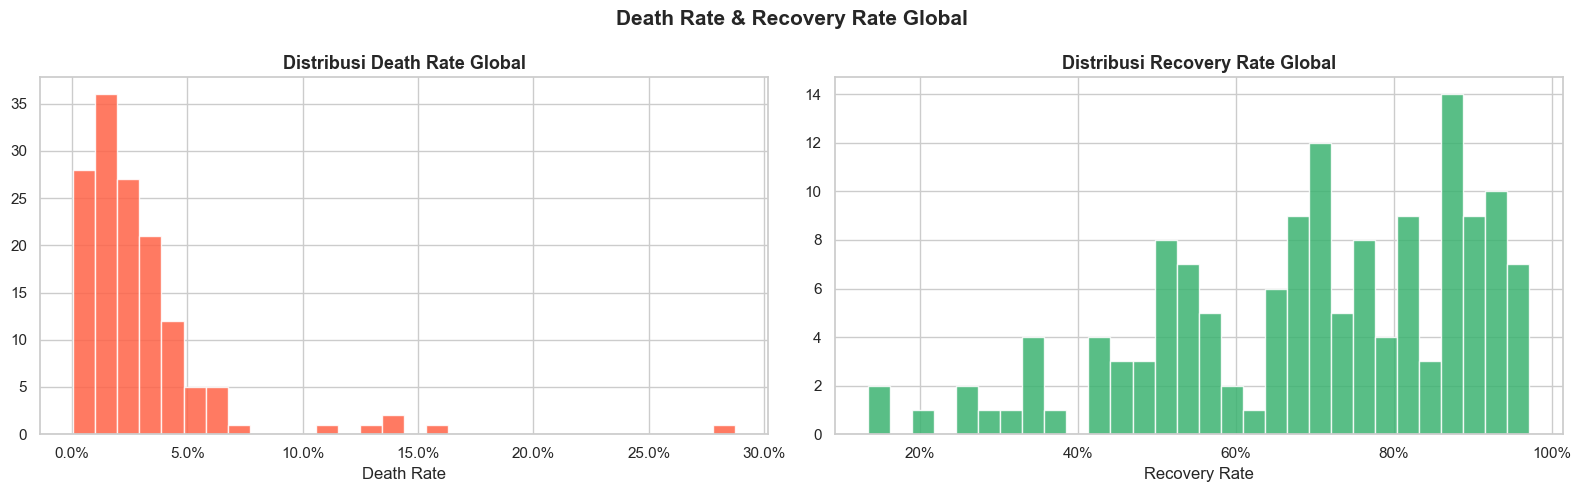

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(dr_rr['Death Rate'], bins=30, color='tomato', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Death Rate Global', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Death Rate')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1%}'))

axes[1].hist(dr_rr['Recovery Rate'].clip(0, 1), bins=30, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi Recovery Rate Global', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recovery Rate')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('Death Rate & Recovery Rate Global', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('death_recovery.png', dpi=100, bbox_inches='tight')
plt.show()

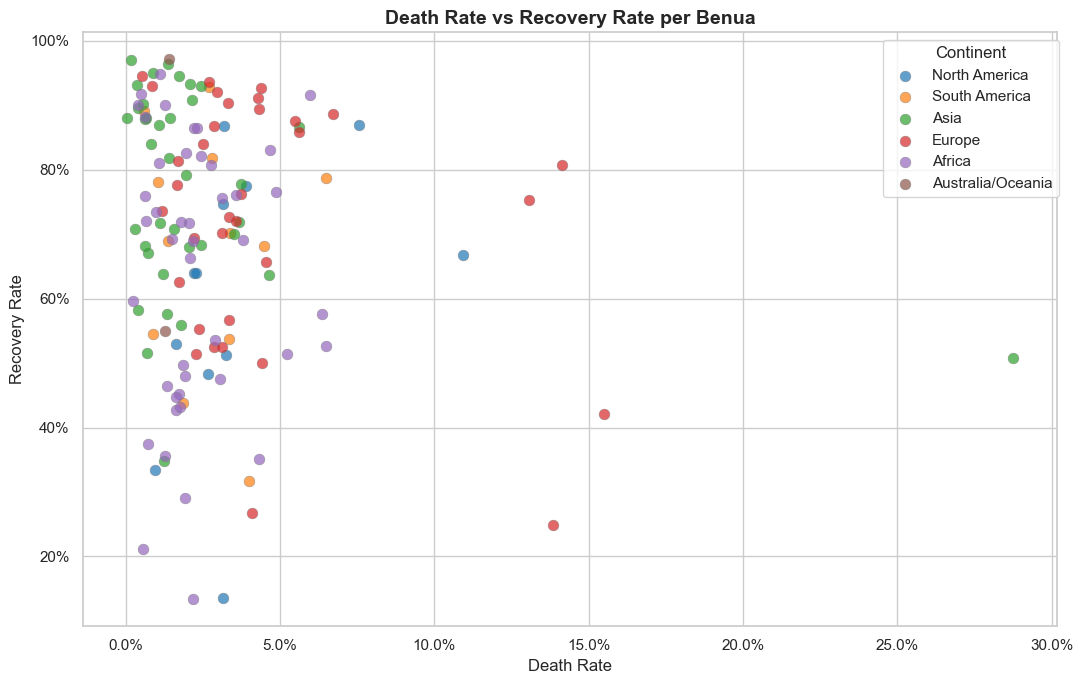

In [14]:
# Scatter: Death Rate vs Recovery Rate per benua
fig, ax = plt.subplots(figsize=(11, 7))
continents = dr_rr['Continent'].dropna().unique()
palette = sns.color_palette('tab10', len(continents))

for cont, color in zip(continents, palette):
    subset = dr_rr[dr_rr['Continent'] == cont]
    ax.scatter(subset['Death Rate'], subset['Recovery Rate'].clip(0,1),
               label=cont, alpha=0.7, edgecolors='grey', linewidths=0.4, s=60, color=color)

ax.set_title('Death Rate vs Recovery Rate per Benua', fontsize=14, fontweight='bold')
ax.set_xlabel('Death Rate')
ax.set_ylabel('Recovery Rate')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(title='Continent', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('death_vs_recovery.png', dpi=100, bbox_inches='tight')
plt.show()

**Insight:**
- Death Rate global rata-rata berkisar antara 2–5%, namun ada outlier dengan death rate >10%  biasanya negara dengan sistem kesehatan kewalahan atau kasus underreported.
- Recovery Rate sebagian besar negara berada di kisaran 70–95%, menunjukkan bahwa mayoritas pasien dapat pulih.
- Terdapat trade-off negatif antara death rate dan recovery rate — negara dengan death rate tinggi umumnya memiliki recovery rate lebih rendah.
- Negara-negara Eropa cenderung memiliki death rate lebih tinggi, possibily karena populasi yang lebih tua dan pelaporan kematian yang lebih komprehensif.


## 6. Serious/Critical Case Analysis

> Visualisasi negara dengan jumlah kasus kritis tertinggi
> Bandingkan dengan jumlah kasus aktif

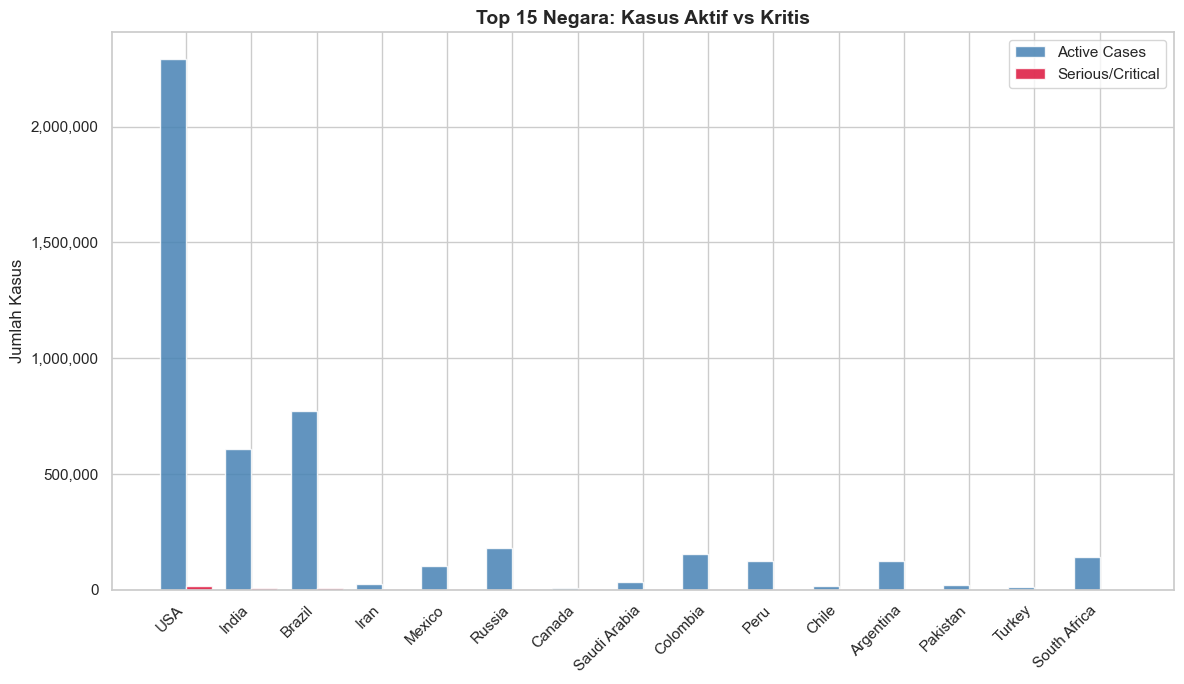

In [15]:
critical = df[['Country/Region', 'Serious,Critical', 'ActiveCases']].dropna()
critical = critical.nlargest(15, 'Serious,Critical')

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(critical))
width = 0.4

ax.bar([i - width/2 for i in x], critical['ActiveCases'], width=width, label='Active Cases', color='steelblue', alpha=0.85)
ax.bar([i + width/2 for i in x], critical['Serious,Critical'], width=width, label='Serious/Critical', color='crimson', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(critical['Country/Region'], rotation=45, ha='right')
ax.set_title('Top 15 Negara: Kasus Aktif vs Kritis', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Kasus')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('critical_cases.png', dpi=100, bbox_inches='tight')
plt.show()

In [16]:
critical['Critical Ratio'] = critical['Serious,Critical'] / critical['ActiveCases'] * 100
print("Persentase Kasus Kritis dari Kasus Aktif (Top 15 Negara):")
display(critical[['Country/Region', 'ActiveCases', 'Serious,Critical', 'Critical Ratio']].sort_values('Critical Ratio', ascending=False))

Persentase Kasus Kritis dari Kasus Aktif (Top 15 Negara):


,Country/Region,ActiveCases,"Serious,Critical",Critical Ratio
23,Canada,6489.0,2263.0,34.874403
10,Iran,24678.0,4156.0,16.840911
7,Chile,16614.0,1358.0,8.173829
12,Saudi Arabia,34082.0,1915.0,5.618802
16,Turkey,10921.0,580.0,5.310869
13,Pakistan,19770.0,809.0,4.092059
5,Mexico,103325.0,3987.0,3.858698
2,India,606387.0,8944.0,1.474966
3,Russia,180931.0,2300.0,1.271203
6,Peru,124648.0,1426.0,1.144022


**Insight:**
- Amerika Serikat memiliki jumlah kasus kritis tertinggi secara absolut, sejalan dengan total kasus yang mendominasi global.
- Ketika melihat rasio kasus kritis terhadap kasus aktif, beberapa negara menunjukkan persentase kritis yang jauh lebih tinggi mengindikasikan tekanan besar pada ICU dan fasilitas kesehatan.
- Tingginya rasio critical menandakan potensi kelebihan beban sistem rumah sakit, yang berdampak pada peningkatan kematian.
- Perbandingan ini penting untuk alokasi sumber daya kesehatan, khususnya ventilator dan tenaga medis ICU.


## 7. Negara dengan Performa Terbaik & Terburuk

> Top 10 negara dengan recovery rate tertinggi
> Top 10 negara dengan death rate tertinggi
> Top 10 negara dengan tests per 1M tertinggi

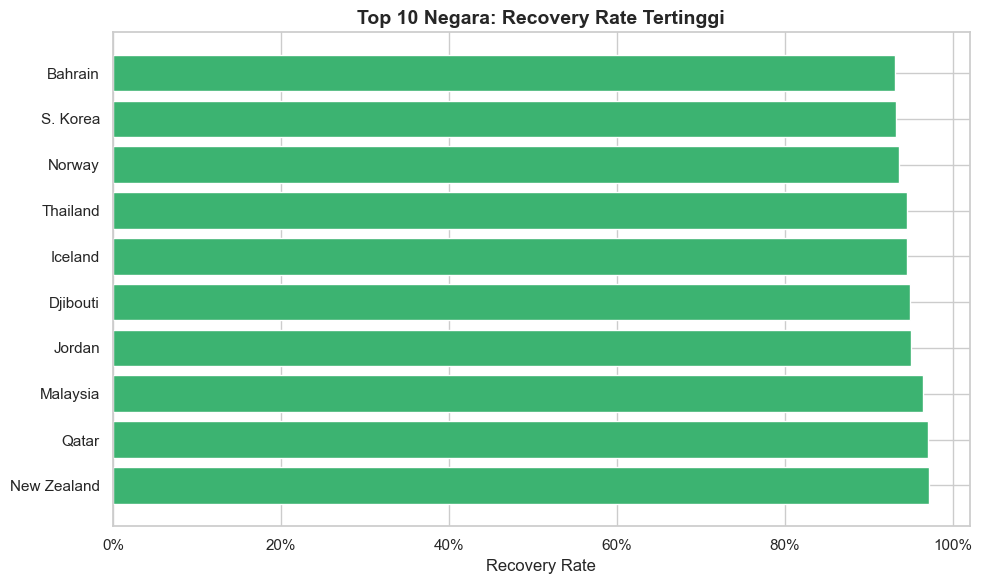

,Country/Region,Continent,TotalCases,Recovery Rate
133,New Zealand,Australia/Oceania,1569,0.971319
24,Qatar,Asia,112092,0.970908
83,Malaysia,Asia,9038,0.964041
137,Jordan,Asia,1232,0.950487
97,Djibouti,Africa,5330,0.948780
129,Iceland,Europe,1930,0.945596
110,Thailand,Asia,3330,0.945345
81,Norway,Europe,9468,0.935467
72,S. Korea,Asia,14519,0.932778
47,Bahrain,Asia,42889,0.931358


In [17]:
dr_rr_filtered = dr_rr[dr_rr['TotalCases'] >= 1000].copy()

top_recovery = dr_rr_filtered.nlargest(10, 'Recovery Rate')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_recovery['Country/Region'], top_recovery['Recovery Rate'], color='mediumseagreen', edgecolor='white')
ax.set_title('Top 10 Negara: Recovery Rate Tertinggi', fontsize=14, fontweight='bold')
ax.set_xlabel('Recovery Rate')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.savefig('top_recovery.png', dpi=100, bbox_inches='tight')
plt.show()
display(top_recovery[['Country/Region', 'Continent', 'TotalCases', 'Recovery Rate']])

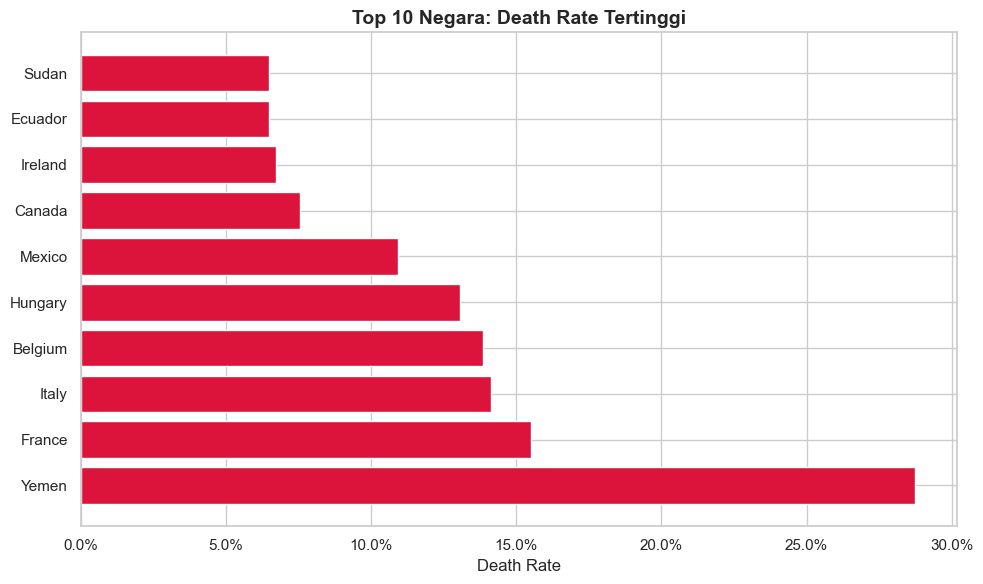

,Country/Region,Continent,TotalCases,Death Rate
131,Yemen,Asia,1768,0.287330
19,France,Europe,195633,0.154943
15,Italy,Europe,249204,0.141198
35,Belgium,Europe,71158,0.138551
103,Hungary,Europe,4597,0.130520
5,Mexico,North America,462690,0.109181
23,Canada,North America,118561,0.075624
60,Ireland,Europe,26372,0.067041
27,Ecuador,South America,90537,0.064913
78,Sudan,Africa,11780,0.064771


In [18]:
top_death = dr_rr_filtered.nlargest(10, 'Death Rate')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_death['Country/Region'], top_death['Death Rate'], color='crimson', edgecolor='white')
ax.set_title('Top 10 Negara: Death Rate Tertinggi', fontsize=14, fontweight='bold')
ax.set_xlabel('Death Rate')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1%}'))
plt.tight_layout()
plt.savefig('top_death.png', dpi=100, bbox_inches='tight')
plt.show()
display(top_death[['Country/Region', 'Continent', 'TotalCases', 'Death Rate']])

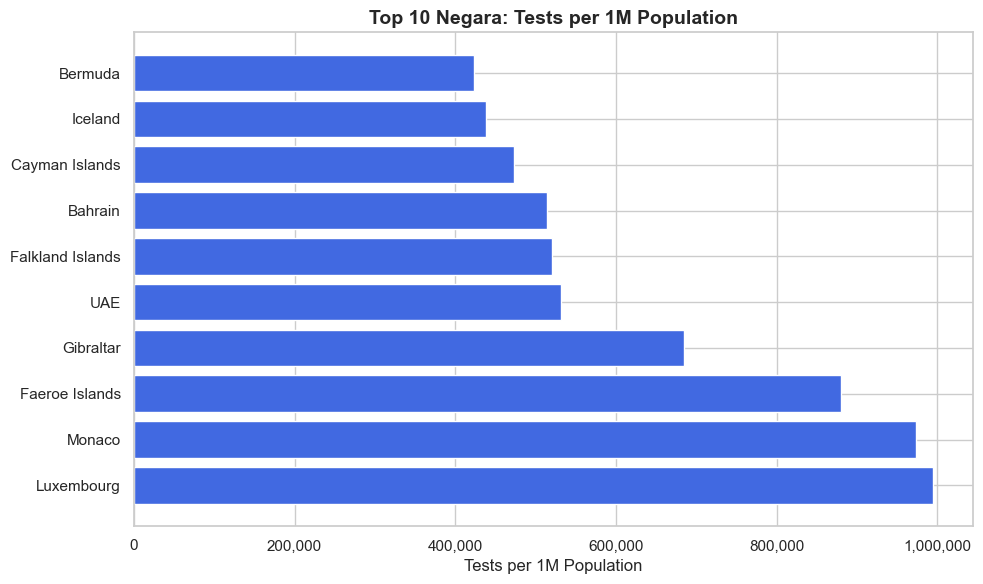

,Country/Region,Continent,Tests/1M pop,TotalTests
91,Luxembourg,Europe,995282.0,623994.0
185,Monaco,Europe,972982.0,38209.0
172,Faeroe Islands,Europe,880590.0,43045.0
177,Gibraltar,Europe,684565.0,23063.0
38,UAE,Asia,531470.0,5262658.0
206,Falkland Islands,South America,520493.0,1816.0
47,Bahrain,Asia,513691.0,876700.0
176,Cayman Islands,North America,472780.0,31108.0
129,Iceland,Europe,438385.0,149693.0
180,Bermuda,North America,423298.0,26352.0


In [19]:
top_tests = df[['Country/Region', 'Continent', 'Tests/1M pop', 'TotalTests']].dropna().nlargest(10, 'Tests/1M pop')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_tests['Country/Region'], top_tests['Tests/1M pop'], color='royalblue', edgecolor='white')
ax.set_title('Top 10 Negara: Tests per 1M Population', fontsize=14, fontweight='bold')
ax.set_xlabel('Tests per 1M Population')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('top_tests.png', dpi=100, bbox_inches='tight')
plt.show()
display(top_tests)

**Insight:**
- Negara-negara dengan recovery rate tertinggi umumnya adalah negara kecil yang berhasil menangani pandemi secara efektif atau memiliki sistem pelaporan yang baik.
-Death rate tertinggi banyak ditemukan di negara-negara yang mengalami gelombang awal pandemi tanpa kesiapan memadai, atau negara dengan populasi tua yang lebih rentan.
- Negara dengan testing per 1 juta populasi tertinggi(seperti negara-negara Teluk dan beberapa negara Eropa) cenderung memiliki data yang lebih akurat karena cakupan testing yang lebih komprehensif.
- Besarnya testing menentukan kualitas data: negara yang banyak melakukan tes cenderung menemukan kasus ringan/tanpa gejala, sehingga death rate mereka relatif lebih rendah.


## 8. Correlation Matrix

> Buat heatmap korelasi untuk kolom numerik
> Apa yang menarik dari korelasi antara populasi, test, dan kasus?

In [20]:
num_cols = ['Population', 'TotalCases', 'TotalDeaths', 'TotalRecovered',
            'ActiveCases', 'Serious,Critical', 'TotalTests', 'Tests/1M pop']

# Only add the rate columns if they exist
if 'Death Rate' in df.columns:
    num_cols.append('Death Rate')
if 'Recovery Rate' in df.columns:
    num_cols.append('Recovery Rate')
if 'Positivity Rate' in df.columns:
    num_cols.append('Positivity Rate')

df_num = df[num_cols].copy()
corr_matrix = df_num.corr()

print(" Correlation Matrix:")
display(corr_matrix.round(2))

 Correlation Matrix:


,Population,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,"Serious,Critical",TotalTests,Tests/1M pop,Death Rate,Recovery Rate,Positivity Rate
Population,1.00,0.55,0.43,0.59,0.46,0.60,0.50,-0.08,0.01,-0.04,0.01
TotalCases,0.55,1.00,0.94,0.99,0.97,0.97,0.89,0.03,0.03,-0.05,-0.02
TotalDeaths,0.43,0.94,1.00,0.94,0.93,0.91,0.85,0.05,0.21,-0.05,-0.02
TotalRecovered,0.59,0.99,0.94,1.00,0.91,0.95,0.87,0.02,0.02,-0.02,-0.02
ActiveCases,0.46,0.97,0.93,0.91,1.00,0.95,0.91,0.03,0.01,-0.09,-0.01
"Serious,Critical",0.60,0.97,0.91,0.95,0.95,1.00,0.86,0.02,0.04,-0.02,0.02
TotalTests,0.50,0.89,0.85,0.87,0.91,0.86,1.00,0.10,0.08,-0.03,-0.03
Tests/1M pop,-0.08,0.03,0.05,0.02,0.03,0.02,0.10,1.00,-0.02,0.24,-0.07
Death Rate,0.01,0.03,0.21,0.02,0.01,0.04,0.08,-0.02,1.00,-0.07,0.32
Recovery Rate,-0.04,-0.05,-0.05,-0.02,-0.09,-0.02,-0.03,0.24,-0.07,1.00,-0.10


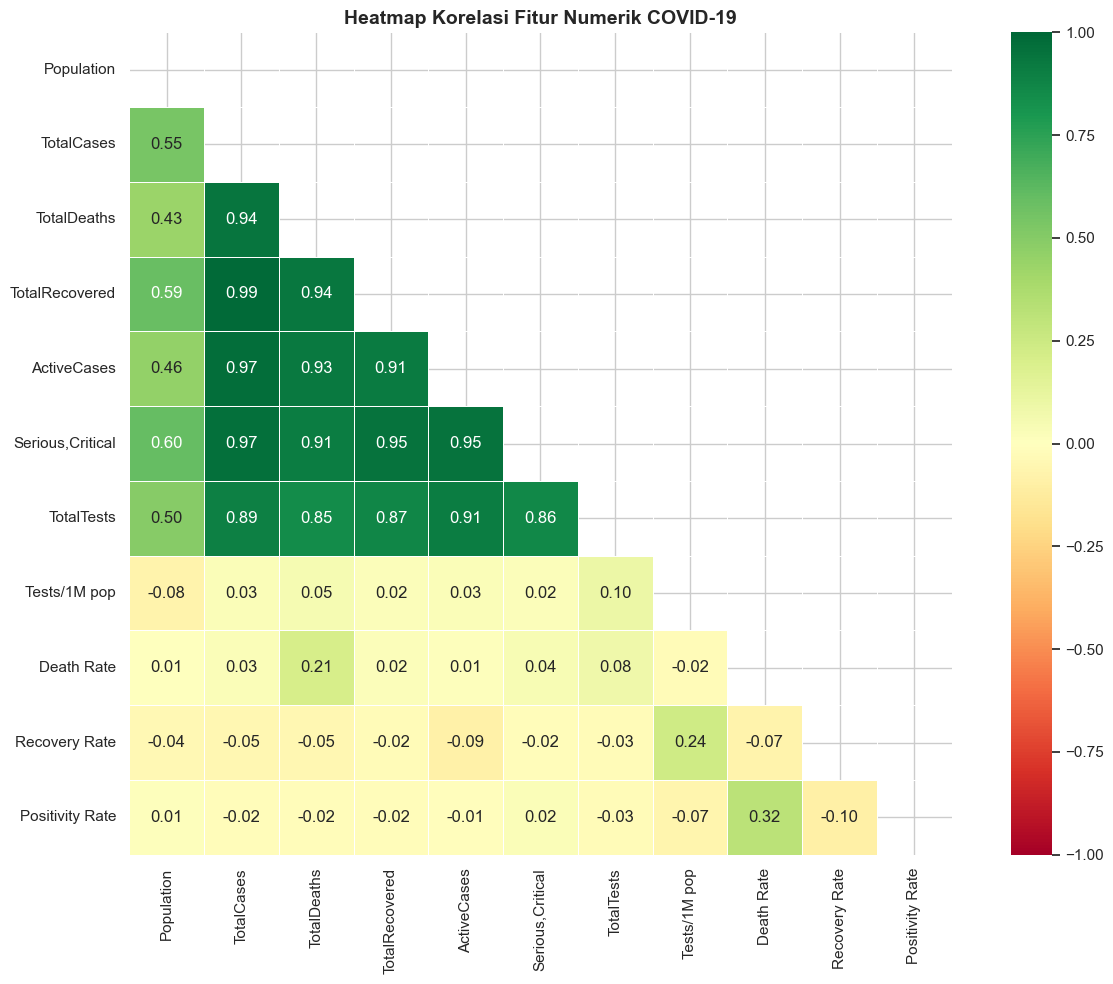

In [21]:
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    square=True,
    vmin=-1, vmax=1
)
ax.set_title('Heatmap Korelasi Fitur Numerik COVID-19', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

**Insight:**
- TotalCases, TotalDeaths, TotalRecovered, dan ActiveCases memiliki korelasi sangat tinggi satu sama lain (>0.9) — wajar karena semua bergantung pada skala pandemi di suatu negara.
- Population dan TotalCasesberkorelasi positif moderat (~0.5–0.7): negara berpopulasi lebih besar tidak otomatis memiliki lebih banyak kasus secara proporsional.
- TotalTests dan TotalCasesberkorelasi tinggi — negara yang banyak melakukan tes cenderung menemukan lebih banyak kasus.
- Positivity Rateberkorelasi negatif dengan `Tests/1M pop` — semakin banyak testing per kapita, semakin rendah positivity rate, mengkonfirmasi bahwa testing masif membantu menekan angka positif relatif.
- Death Rate dan **Recovery Rate** berkorelasi negatif signifikan — semakin tinggi angka kematian, semakin rendah tingkat kesembuhan.


## 9. Kesimpulan

Berdasarkan Exploratory Data Analysis (EDA) pada dataset Worldometer COVID-19 yang mencakup 209 negara/wilayah, berikut adalah kesimpulan utama:

- Dataset memiliki 16 fitur mencakup jumlah kasus, kematian, kesembuhan, tes, dan informasi geografis.
- Banyak missing value pada data baru (NewCases, NewDeaths, NewRecovered) karena snapshot diambil pada waktu tertentu.

- Distribusi data sangat right-skewed sebagian kecil negara bertanggung jawab atas sebagian besar kasus global.
- Amerika Serikat mendominasi dengan kasus terbanyak (~5 juta pada saat data diambil).
- Dalam skala logaritmik, distribusi kasus mendekati normal — menunjukkan variabilitas antar negara yang bersifat eksponensial.

-  Amerika Utara dan Eropa memiliki kasus dan kematian tertinggi secara absolut.
- Afrika dan Oseania mencatat angka terendah, namun positivity rate tinggi mengindikasikan underreporting yang signifikan.

- Negara-negara dengan testing rendah memiliki positivity rate jauh di atas ambang WHO (5%), menandakan banyak kasus yang tidak terdeteksi.
- Testing masif terbukti efektif menurunkan positivity rate dan memberikan gambaran pandemi yang lebih akurat.

- Death rate global rata-rata ~2–5%, dengan outlier di atas 10% pada beberapa negara.
- Recovery rate sebagian besar negara berada di atas 70%, namun bervariasi bergantung kapasitas sistem kesehatan.

- Jumlah kasus, kematian, dan kesembuhan sangat berkorelasi satu sama lain.
- Testing masif berkorelasi positif dengan penemuan kasus namun negatif dengan positivity rate   menggarisbawahi pentingnya cakupan tes.
